# 一、 Torch 安装方法

CPU   pip3 install torch  -i https://download.pytorch.org/whl/torch_stable.html

GPU  CUDA 和对应的torch版本



In [1]:
#pip3 install torch


SyntaxError: invalid syntax (845456919.py, line 1)

In [ ]:
print('==============>');

In [8]:
import torch;
print(torch.__version__);



import numpy

print(numpy.__version__);


2.4.1+cpu
1.24.4


# 二、下载MNIST数据集



loadwond ok !!!
(50000, 784)


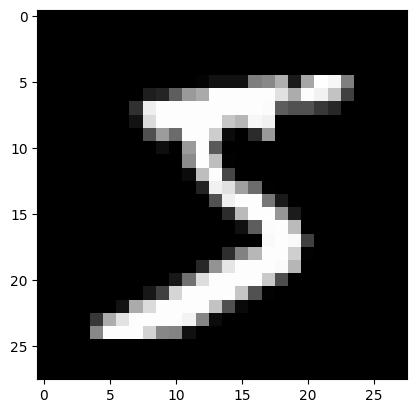

In [28]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt;
from matplotlib import pyplot;
import numpy as np;
import torch;
#import torch.utils.data as tud;
from torch.utils.data import TensorDataset;
from torch.utils.data import DataLoader;


# USE_CUDA = torch.cuda.is_available();

# 下载MNIST数据集
# transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
# trainset = datasets.MNIST('data/MNIST_data/', download=True, train=True, transform=transform)
# testset = datasets.MNIST('data/MNIST_data/', download=True, train=False, transform=transform)



# print(trainset);
# print(trainset[10]);
# print(trainset.shape);
# 可视化数据集图像
# n = 10  # 展示10张图像
# plt.figure(figsize=(10, 5))
# for i in range(n):
#     images, labels = trainset[i]
#     plt.subplot(2, 5, i+1)
#     plt.imshow(images[0].view(28, 28), cmap='gray')
#     plt.title(f'Label: {labels}')
# plt.show()
#plt.imshow(images[0].view(28, 28), cmap='gray')



# https://resources.oreilly.com/live-training/inside-unsupervised-learning/-/raw/master/data/mnist_data/mnist.pkl.gz?
from pathlib  import Path;

import requests;

DATA_PATH = Path('data');

# 下载字体数据集目录的位置
PATH = DATA_PATH / 'mnist';

PATH.mkdir(parents=True, exist_ok=True);

URL = 'https://resources.oreilly.com/live-training/inside-unsupervised-learning/-/raw/master/data/mnist_data/';

FILENAME = 'mnist.pkl.gz';


if not (PATH / FILENAME).exists():
   content = requests.get(URL + FILENAME).content;
   (PATH / FILENAME).open('wb').write(content);

print('loadwond ok !!!');


import pickle
import gzip
# 打开下载的pkl.gz文件
with gzip.open((PATH / FILENAME).as_posix(), 'rb') as f:
    #mnist_data = pickle.load(f, encoding='latin1');
    ((x_train, y_train), (x_valid, y_valid), _) = pickle.load(f, encoding='latin-1');
# mnist_data现在是一个包含两个元素的元组
# 第一个元素是训练数据集，第二个元素是测试数据集
#train_data, test_data = mnist_data
# 训练数据集包含70000个样本和784个特征
# 测试数据集包含10000个样本和784个特征

pyplot.imshow(x_train[0].reshape(28, 28), cmap='gray')
print(x_train.shape);

# print(y_train.shape);


# 三、张量


In [29]:
# x_train, _ = trainset[0];
# y_train, _ = trainset[1];
# x_valid, _ = trainset[2];
# y_valid, _ = trainset[3];



x_train, y_train, x_valid, y_valid = map(torch.tensor, (x_train, y_train, x_valid, y_valid ));


#n, c = x_train.shape; 
x_train, x_train.shape, y_train.min(), y_train.max();
print(x_train, y_train);
print('------------x_train.shap---------------');
print(x_train.shape);
print(y_train.min(), y_train.max());

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]]) tensor([5, 0, 4,  ..., 8, 4, 8])
------------x_train.shap---------------
torch.Size([50000, 784])
tensor(0) tensor(9)


In [14]:
print(x_train.shape);

torch.Size([1, 28, 28])


# 四、定义神经网络结构二层

In [30]:

print('-------------------------定义神经网络二层结构tarn-------------------------------------------');
#  创建一个model来更简化代码
#      1. 必须继承nn.Module 且在构造函数中需调用nn.Module的构造函数
#      2. 无需写反向传播函数， nn.Moudle能够利用autograd自动实现反向传播
#      3. Module中的可学习参数可以通过named_parameters()或者parameters()返回迭代器
from torch import nn ;

class Mnist_NN(nn.Module):
    def __init__(self):
        super().__init__()
        #  全链接一层    输入 784特征值  输出 128特征值
        self.hidden1 = nn.Linear(784, 128);
        #  全链接二层   输入 128  输出 256
        self.hidden2 = nn.Linear(128, 256);
        
        # 分类输出 10
        self.out = nn.Linear(256, 10);
        #  暴裂因子
        self.dropout = nn.Dropout(0.5);
    # 1. 前向传播  => 需要我们自己定义怎么走动   
    # 2. 反向传播  => 是自动哈 不需要我们定义怎么走动啦~~~
    def forward(self, x):
        x = F.relu(self.hidden1(x));
        x = self.dropout(x);
        x = F.relu(self.hidden2(x));
        x = self.dropout(x);
        x = self.out(x);
        return x;




# 输出结构

net =  Mnist_NN();
print(net);

print('---------------------------------------');


for name, parameter in net.named_parameters():
    print(name, parameter, parameter.size());

 

-------------------------定义神经网络二层结构tarn-------------------------------------------
Mnist_NN(
  (hidden1): Linear(in_features=784, out_features=128, bias=True)
  (hidden2): Linear(in_features=128, out_features=256, bias=True)
  (out): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)
---------------------------------------
hidden1.weight Parameter containing:
tensor([[ 0.0178, -0.0080,  0.0350,  ...,  0.0186,  0.0353,  0.0064],
        [ 0.0339,  0.0056,  0.0272,  ...,  0.0192, -0.0287,  0.0140],
        [-0.0331, -0.0029,  0.0311,  ..., -0.0093,  0.0099, -0.0218],
        ...,
        [ 0.0124, -0.0195,  0.0250,  ...,  0.0262, -0.0034, -0.0260],
        [ 0.0266,  0.0198, -0.0261,  ..., -0.0027, -0.0105, -0.0019],
        [-0.0193,  0.0029, -0.0034,  ..., -0.0040, -0.0105,  0.0203]],
       requires_grad=True) torch.Size([128, 784])
hidden1.bias Parameter containing:
tensor([-9.0211e-03, -2.7427e-02, -1.3610e-02,  3.3292e-02,  9.4121e-03,


# 五、 使用TensorDataset 和 DataLoader来简化

In [31]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np;
#import torch.utils.data as tud;
from torch.utils.data import TensorDataset;
from torch.utils.data import DataLoader;
bs = 64;  # ====》 64、128、256


train_ds = TensorDataset(x_train, y_train);
# DataLoader 作用是从数据中打包train_ds向 CPU或者GPU送数据包一次的大小
#        |      data    |
#  mem   | train_ds = 64 | 64 | 64 |
#            
# GPU/CPU|   train_ds =64 |   
#    batch_size 一批多少个包 
train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True);


valid_ds = TensorDataset(x_valid, y_valid);
valid_dl = DataLoader(valid_ds, batch_size=bs*2);


def get_data(train_ds, valid_ds, bs):
    return (DataLoader(train_ds, batch_size=bs, shuffle=True),
            DataLoader(valid_ds, batch_size=bs * 2));

#  一般在train 模型时加上model.train(), 这样会正常使用Batch Normalization和Dropout
#  测试的时候一般选择model.eval(), 这样就不会使用 Batch Normlization 和Dropout


# 六、 tarn


In [32]:
import numpy as np;
import torch.nn.functional  as F;

loss_func = F.cross_entropy;


def fit(setps, model, loss_func, opt, train_dl, valid_dl):
    for step in range(setps):
        #  训练模式 需要每次更新权重参数weight的
        model.train();
        for xb, yb in train_dl:
            loss_batch(model, loss_func, xb, yb, opt);
        # 验证模式  不更新权重参数
        model.eval();
        with torch.no_grad():
            losses, nums = zip(
                *[loss_batch(model, loss_func, xb, yb) for xb, yb in valid_dl]
            );
        val_loss = np.sum(np.multiply(losses, nums)) / np.sum(nums);
        print('当前step: ' + str(step), '验证集损失:' + str(val_loss));
    

In [ ]:
# test

a = [1, 2, 3];
b = [4, 5, 6];
zipped = zip(a, b);

print(list(zipped));

a2, b2 = zip(*zip(a, b));
print(a2);
print(b2);

In [42]:

from torch import optim;


# optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# 确保访问的是正确的属性
# print(optim.defaults_dict) # 替代 defaults


def get_model():
    model = Mnist_NN();
    return model, optim.SGD(model.parameters(), lr=0.001); # Adam





In [44]:
def loss_batch(model, loss_func, xb, yb, opt=None):
    loss = loss_func(model(xb), yb);

    if opt is not None:
        loss.backward();
        opt.step();
        opt.zero_grad();
        
    return loss.item(), len(xb);


In [45]:


train_dl, valid_dl = get_data(train_ds, valid_ds, bs);
model, opt = get_model();
fit(100, model, loss_func, opt, train_dl, valid_dl);


当前step: 0 验证集损失:2.2828175704956055
当前step: 1 验证集损失:2.259421767425537
当前step: 2 验证集损失:2.2277550563812256
当前step: 3 验证集损失:2.1812951221466066
当前step: 4 验证集损失:2.111326621246338
当前step: 5 验证集损失:2.0069704734802247
当前step: 6 验证集损失:1.8604523498535157
当前step: 7 验证集损失:1.6745574096679687
当前step: 8 验证集损失:1.4665144561767578
当前step: 9 验证集损失:1.2717118255615234
当前step: 10 验证集损失:1.1110467895507812
当前step: 11 验证集损失:0.9871484380722045
当前step: 12 验证集损失:0.8909065502166748
当前step: 13 验证集损失:0.8146784567832946
当前step: 14 验证集损失:0.7547967977523804
当前step: 15 验证集损失:0.7056966060638428
当前step: 16 验证集损失:0.6642692462921143
当前step: 17 验证集损失:0.6283276700019836
当前step: 18 验证集损失:0.5976921843528747
当前step: 19 验证集损失:0.5715237950325012
当前step: 20 验证集损失:0.5486700281143189
当前step: 21 验证集损失:0.5273529270172119
当前step: 22 验证集损失:0.5090466154098511
当前step: 23 验证集损失:0.4923228448867798
当前step: 24 验证集损失:0.47773199796676635
当前step: 25 验证集损失:0.4640382312297821
当前step: 26 验证集损失:0.45157003746032714
当前step: 27 验证集损失:0.4404550605773926
当前